<a href="https://colab.research.google.com/github/NYChase/IBMDataScienceProjects/blob/Machine-Learning-with-Python/Regression_Trees_Taxi_Tip_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Regression Trees**


Estimated time needed: **30** minutes


In this exercise session you will use a real dataset to train a regression tree model. The dataset includes information about taxi tip and was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers authorized under the Taxicab & Livery Passenger Enhancement Programs (TPEP/LPEP). You will use the trained model to predict the amount of tip paid.



## Objectives


After completing this lab you will be able to:


* Perform basic data preprocessing using Scikit-Learn
* Model a regression task using Scikit-Learn
* Train a Decision Tree Regressor model
* Run inference and assess the quality of the trained models


<h2>Introduction</h2>
The dataset used in this exercise session is a subset of the publicly available <a><href='https://www1.nyc.gov/site/tlc/about/tlc-trip-record-data.page'>TLC Dataset</a> (all rights reserved by Taxi & Limousine Commission (TLC), City of New York). The prediction of the tip amount can be modeled as a regression problem. To train the model you can use part of the input dataset and the remaining data can be used to assess the quality of the trained model.
    <br>
</div>


<div id="import_libraries">
    <h2>Import Libraries</h2>
</div>


Make sure the libraries required are available by executing the cell below.


In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

Import the libraries we need to use in this lab


In [2]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

<div id="dataset_analysis">
    <h2>Dataset Analysis</h2>
</div>


In this section you will read the dataset in a Pandas dataframe and visualize its content. You will also look at some data statistics.

Note: A Pandas dataframe is a two-dimensional, size-mutable, potentially heterogeneous tabular data structure. For more information: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html.


In [3]:
# read the input data
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
raw_data = pd.read_csv(url)
raw_data

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19


Each row in the dataset represents a taxi trip. As shown above, each row has 13 variables. One of the variables is `tip_amount` which will be the target variable. Your objective will be to train a model that uses the other variables to predict the value of the `tip_amount` variable.


To understand the dataset a little better, let us plot the correlation of the target variable against the input variables.


<Axes: >

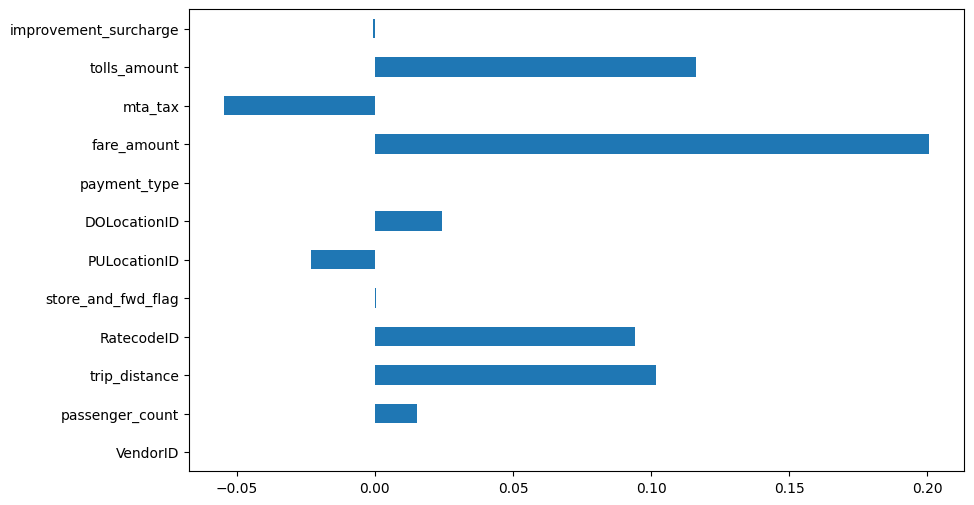

In [4]:
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
correlation_values.plot(kind='barh', figsize=(10, 6))

This shows us that the input features `payment_type`, `VendorID`, `store_and_fwd_flag` and `improvement_surcharge` have little to no correlation with the target variable.


<div id="dataset_preprocessing">
    <h2>Dataset Preprocessing</h2>
</div>


You will now prepare the data for training by applying normalization to the input features.


In [5]:
# extract the labels from the dataframe
y = raw_data[['tip_amount']].values.astype('float32')

# drop the target variable from the feature matrix
proc_data = raw_data.drop(['tip_amount'], axis=1)

# get the feature matrix used for training
X = proc_data.values

# normalize the feature matrix
X = normalize(X, axis=1, norm='l1', copy=False)

<div id="dataset_split">
    <h2>Dataset Train/Test Split</h2>
</div>


Now that the dataset is ready for building the classification models, you need to first divide the pre-processed dataset into a subset to be used for training the model (the train set) and a subset to be used for evaluating the quality of the model (the test set).


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<div id="dt_sklearn">
    <h2>Build a Decision Tree Regressor model with Scikit-Learn</h2>
</div>


Regression Trees are implemented using `DecisionTreeRegressor`.

The important parameters of the model are:

`criterion`: The function used to measure error, we use 'squared_error'.

`max_depth` - The maximum depth the tree is allowed to take; we use 8.


In [7]:
# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# for reproducible output across multiple function calls, set random_state to a given integer value
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8,
                               random_state=35)

Now lets train our model using the `fit` method on the `DecisionTreeRegressor` object providing our training data


In [8]:
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

<div id="dt_sklearn_snapml">
    <h2>Evaluate the Scikit-Learn and Snap ML Decision Tree Regressor Models</h2>
</div>


To evaluate our dataset we will use the `score` method of the `DecisionTreeRegressor` object providing our testing data, this number is the $R^2$ value which indicates the coefficient of determination. We will also evaluate the Mean Squared Error $(MSE)$ of the regression output with respect to the test set target values. High $R^2$ and low $MSE$ values are expected from a good regression model.


In [9]:
# run inference using the sklearn model
y_pred = dt_reg.predict(X_test)

# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.555
R^2 score : 0.028


## Practice


Q1. What if we change the max_depth to 12? How would the $MSE$ and $R^2$ be affected?


In [10]:
# Create a new Decision Tree Regressor model with max_depth=12
dt_reg_12 = DecisionTreeRegressor(criterion='squared_error',
                                  max_depth=12,
                                  random_state=35)

# Train the new model
dt_reg_12.fit(X_train, y_train)

# Run inference using the new model
y_pred_12 = dt_reg_12.predict(X_test)

# Evaluate mean squared error on the test dataset
mse_score_12 = mean_squared_error(y_test, y_pred_12)
print('MSE score with max_depth=12: {0:.3f}'.format(mse_score_12))

# Evaluate R^2 score on the test dataset
r2_score_12 = dt_reg_12.score(X_test, y_test)
print('R^2 score with max_depth=12: {0:.3f}'.format(r2_score_12))

MSE score with max_depth=12: 26.459
R^2 score with max_depth=12: -0.047


Comparing this to the original model with max_depth=8, where the MSE was approximately 24.555 and the $R^2$$R^2$ score was approximately 0.028, we can see the following:

* MSE increased: A higher MSE indicates that the model's predictions are, on average, further away from the actual tip amounts.
* $R^2$$R^2$ decreased and became negative: The $R^2$$R^2$ score measures the proportion of the variance in the dependent variable (tip amount) that is predictable from the independent variables. A negative $R^2$$R^2$ score is unusual and indicates that the model fits the data worse than a horizontal line (the mean of the dependent variable).
These results suggest that increasing the max_depth to 12 caused the model to overfit the training data. Overfitting happens when a model learns the training data too well, including the noise and random fluctuations, which negatively impacts its ability to generalize to unseen data (the test set).

The negative $R^2$$R^2$ score is a strong indicator of poor model performance on the test set, suggesting that increasing the max_depth in this case was detrimental to the model's predictive power.

<details><summary>Click here for the solution</summary>
MSE is noted to be increased by increasing the max_depth of the tree. This may be because of the model having excessive parameters due to which it overfits to the training data, making the performance on the testing data poorer. Another important observation would be that the model gives a <b>negative</b> value of $R^2$. This again indicates that the prediction model created does a very poor job of predicting the values on a test set.
</details>


Q2. Identify the top 3 features with the most effect on the `tip_amount`.


In [11]:
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
print("Top 3 features affecting tip_amount:")
print(abs(correlation_values).sort_values(ascending=False)[:3])

Top 3 features affecting tip_amount:
fare_amount      0.200638
tolls_amount     0.116172
trip_distance    0.101819
Name: tip_amount, dtype: float64


<details><summary>Click here for the solution</summary>

```python    
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')
abs(correlation_values).sort_values(ascending=False)[:3]

```
<br>
As is evident from the output, Fare amount, toll amount and trip distance are the top features affecting the tip amount, which make logical sense.
</details>


Q3. Since we identified 4 features which are not correlated with the target variable, try removing these variables from the input set and see the effect on the $MSE$ and $R^2$ value.


In [12]:
# Remove the low-correlation features
raw_data_reduced = raw_data.drop(['payment_type', 'VendorID', 'store_and_fwd_flag', 'improvement_surcharge'], axis=1)

# extract the labels from the dataframe
y_reduced = raw_data_reduced[['tip_amount']].values.astype('float32')

# drop the target variable from the feature matrix
proc_data_reduced = raw_data_reduced.drop(['tip_amount'], axis=1)

# get the feature matrix used for training
X_reduced = proc_data_reduced.values

# normalize the feature matrix
X_reduced = normalize(X_reduced, axis=1, norm='l1', copy=False)

# Split the data into training and testing sets
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y_reduced, test_size=0.3, random_state=42)

# Create and train a new Decision Tree Regressor model
dt_reg_reduced = DecisionTreeRegressor(criterion = 'squared_error',
                                       max_depth=8,  # Using the original max_depth for comparison
                                       random_state=35)
dt_reg_reduced.fit(X_train_reduced, y_train_reduced)

# Run inference using the new model
y_pred_reduced = dt_reg_reduced.predict(X_test_reduced)

# Evaluate mean squared error on the test dataset
mse_score_reduced = mean_squared_error(y_test_reduced, y_pred_reduced)
print('MSE score after removing low-correlation features: {0:.3f}'.format(mse_score_reduced))

# Evaluate R^2 score on the test dataset
r2_score_reduced = dt_reg_reduced.score(X_test_reduced, y_test_reduced)
print('R^2 score after removing low-correlation features: {0:.3f}'.format(r2_score_reduced))

MSE score after removing low-correlation features: 24.709
R^2 score after removing low-correlation features: 0.022


After removing the features with low correlation (payment_type, VendorID, store_and_fwd_flag, and improvement_surcharge), the MSE score is approximately 24.709 and the R-squared ($R^2$$R^2$) score is approximately 0.022.

Comparing this to the original model with all features (where MSE was approximately 24.555 and $R^2$$R^2$ was approximately 0.028), we can see that removing these features had a minimal effect on both the MSE and $R^2$$R^2$ values.

**This suggests that the features with low correlation indeed had little impact on the model's ability to predict the tip_amount, and removing them did not significantly improve or worsen the model's performance in terms of these metrics.**

<details><summary>Click here for the solution</summary>

```python
raw_data = raw_data.drop(['payment_type', 'VendorID', 'store_and_fwd_flag', 'improvement_surcharge'], axis=1)

# Execute all the cells of the lab after modifying the raw data.
```
<br>
The MSE and $R^2$ values does not change significantly, showing that there is minimal affect of these parameters on the final regression output.
</details>


Q4. Check the effect of **decreasing** the `max_depth` parameter to 4 on the $MSE$ and $R^2$ values.


In [13]:
# Create a new Decision Tree Regressor model with max_depth=4
dt_reg_4 = DecisionTreeRegressor(criterion='squared_error',
                                 max_depth=4,
                                 random_state=35)

# Train the new model
dt_reg_4.fit(X_train, y_train)

# Run inference using the new model
y_pred_4 = dt_reg_4.predict(X_test)

# Evaluate mean squared error on the test dataset
mse_score_4 = mean_squared_error(y_test, y_pred_4)
print('MSE score with max_depth=4: {0:.3f}'.format(mse_score_4))

# Evaluate R^2 score on the test dataset
r2_score_4 = dt_reg_4.score(X_test, y_test)
print('R^2 score with max_depth=4: {0:.3f}'.format(r2_score_4))

MSE score with max_depth=4: 24.412
R^2 score with max_depth=4: 0.034


<details><summary>Click here for the solution</summary>
You will note that the MSE value decreases and $R^2$ value increases, meaning that the choice of `max_depth=4` may be more suited for this dataset.
</details>


### Congratulations! You're ready to move on to your next lesson!

## Author
<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>

### Other Contributors
<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>  

<h3 align="center"> © IBM Corporation. All rights reserved. <h3/>


<!--
## Change Log


|  Date (YYYY-MM-DD) |  Version       | Changed By     | Change Description                  |
|---|---|---|---|
| 2024-10-31         | 3.0            | Abhishek Gagneja  | Rewrite                             |
| 2020-11-03         | 2.1            | Lakshmi        | Made changes in URL                 |
| 2020-11-03         | 2.1            | Lakshmi        | Made changes in URL                 |
| 2020-08-27         | 2.0            | Lavanya        | Moved lab to course repo in GitLab  |
|   |   |   |   |


# Task
Find the optimal `max_depth` parameter for the Decision Tree Regressor model by iterating through a range of values, training and evaluating the model for each value, and visualizing the results to identify the `max_depth` that yields the best performance.

## Define a range of `max depth` values

### Subtask:
Define a range of integer values to test for the `max_depth` parameter.


**Reasoning**:
Create a list of integer values for the max_depth parameter to iterate through.



In [14]:
max_depth_range = list(range(1, 21)) # Test max_depth from 1 to 20

## Iterate through `max depth` values

### Subtask:
Loop through each value in the defined range of `max_depth_range`.


**Reasoning**:
Loop through the defined range of max_depth values to prepare for training and evaluating the model for each value.



In [15]:
for max_depth in max_depth_range:
    print(f"Testing max_depth = {max_depth}")
    # The subsequent steps of training and evaluating the model will be performed inside this loop

Testing max_depth = 1
Testing max_depth = 2
Testing max_depth = 3
Testing max_depth = 4
Testing max_depth = 5
Testing max_depth = 6
Testing max_depth = 7
Testing max_depth = 8
Testing max_depth = 9
Testing max_depth = 10
Testing max_depth = 11
Testing max_depth = 12
Testing max_depth = 13
Testing max_depth = 14
Testing max_depth = 15
Testing max_depth = 16
Testing max_depth = 17
Testing max_depth = 18
Testing max_depth = 19
Testing max_depth = 20


## Train and evaluate the model

### Subtask:
For each `max_depth`, train a Decision Tree Regressor model and evaluate its performance using metrics like MSE and R2 on the test set.


**Reasoning**:
Iterate through the defined `max_depth` range, train a Decision Tree Regressor for each depth, and calculate the MSE and R2 scores.



In [16]:
mse_scores = []
r2_scores = []

for max_depth in max_depth_range:
    print(f"Testing max_depth = {max_depth}")
    # Instantiate a DecisionTreeRegressor object
    dt_reg = DecisionTreeRegressor(criterion='squared_error',
                                   max_depth=max_depth,
                                   random_state=35)

    # Train the model
    dt_reg.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = dt_reg.predict(X_test)

    # Calculate MSE
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)

    # Calculate R2 score
    r2 = dt_reg.score(X_test, y_test)
    r2_scores.append(r2)

print("Completed training and evaluation for all max_depth values.")

Testing max_depth = 1
Testing max_depth = 2
Testing max_depth = 3
Testing max_depth = 4
Testing max_depth = 5
Testing max_depth = 6
Testing max_depth = 7
Testing max_depth = 8
Testing max_depth = 9
Testing max_depth = 10
Testing max_depth = 11
Testing max_depth = 12
Testing max_depth = 13
Testing max_depth = 14
Testing max_depth = 15
Testing max_depth = 16
Testing max_depth = 17
Testing max_depth = 18
Testing max_depth = 19
Testing max_depth = 20
Completed training and evaluation for all max_depth values.


## Visualize results

### Subtask:
Plot the MSE and R2 scores against the `max_depth` values to visualize the performance trend.


**Reasoning**:
Create a figure with two subplots and plot the MSE and R2 scores against the max_depth values to visualize the performance trend.



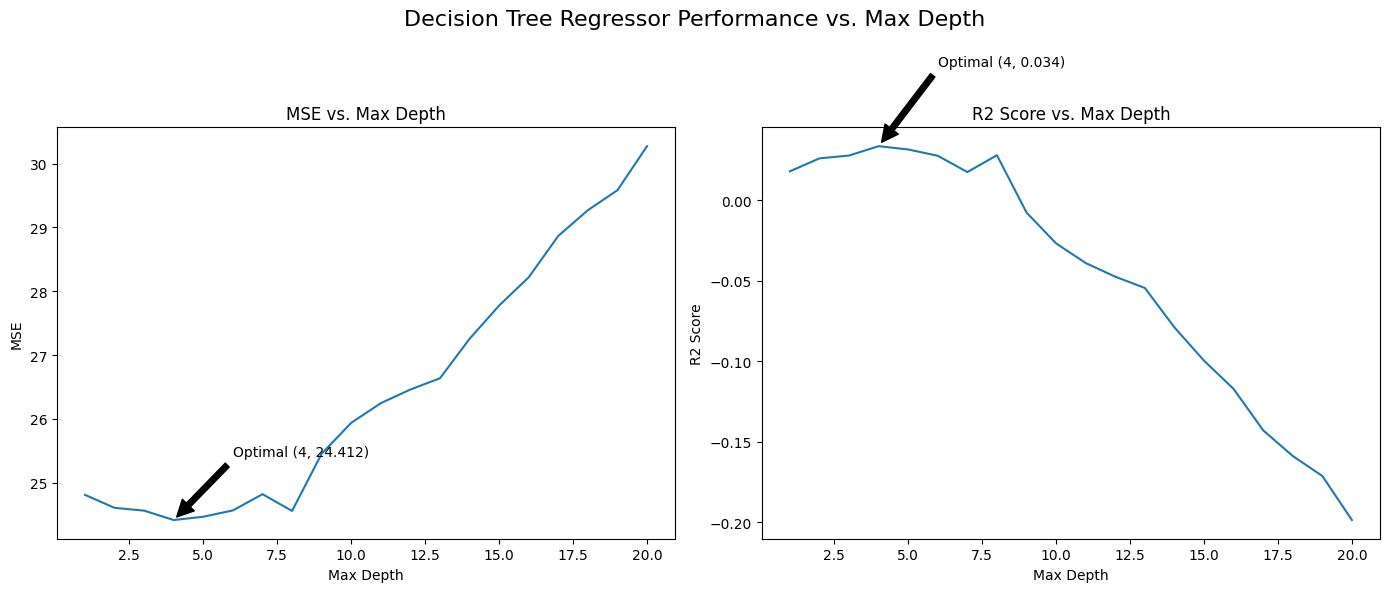

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot MSE vs. Max Depth
axes[0].plot(max_depth_range, mse_scores)
axes[0].set_xlabel("Max Depth")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs. Max Depth")
# Label the optimal point for MSE
axes[0].annotate(f'Optimal ({optimal_max_depth_mse}, {mse_scores[min_mse_index]:.3f})',
                 xy=(optimal_max_depth_mse, mse_scores[min_mse_index]),
                 xytext=(optimal_max_depth_mse + 2, mse_scores[min_mse_index] + 1),
                 arrowprops=dict(facecolor='black', shrink=0.05))


# Plot R2 Score vs. Max Depth
axes[1].plot(max_depth_range, r2_scores)
axes[1].set_xlabel("Max Depth")
axes[1].set_ylabel("R2 Score")
axes[1].set_title("R2 Score vs. Max Depth")
# Label the optimal point for R2
axes[1].annotate(f'Optimal ({optimal_max_depth_r2}, {r2_scores[max_r2_index]:.3f})',
                 xy=(optimal_max_depth_r2, r2_scores[max_r2_index]),
                 xytext=(optimal_max_depth_r2 + 2, r2_scores[max_r2_index] + 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05))


# Add a main title to the figure
fig.suptitle("Decision Tree Regressor Performance vs. Max Depth", fontsize=16)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

## Identify optimal `max depth`

### Subtask:
Determine the `max_depth` value that corresponds to the best performance (e.g., lowest MSE or highest R2).


**Reasoning**:
Calculate and print the optimal max_depth based on the minimum MSE and maximum R2 scores.



In [18]:
# Find the index of the minimum MSE
min_mse_index = np.argmin(mse_scores)
optimal_max_depth_mse = max_depth_range[min_mse_index]

# Find the index of the maximum R2 score
max_r2_index = np.argmax(r2_scores)
optimal_max_depth_r2 = max_depth_range[max_r2_index]

print(f"Optimal max_depth based on minimum MSE: {optimal_max_depth_mse}")
print(f"Optimal max_depth based on maximum R2 score: {optimal_max_depth_r2}")

Optimal max_depth based on minimum MSE: 4
Optimal max_depth based on maximum R2 score: 4


## Summary:

### Data Analysis Key Findings

*   The process involved training Decision Tree Regressor models with `max_depth` values ranging from 1 to 20.
*   For each `max_depth`, the model's performance was evaluated using Mean Squared Error (MSE) and R-squared (R2) scores on the test set.
*   Visualizations of the MSE and R2 scores against the `max_depth` values were generated to observe performance trends.
*   The `max_depth` value that resulted in the minimum MSE was 4.
*   The `max_depth` value that resulted in the maximum R2 score was 4.

### Insights or Next Steps

*   The optimal `max_depth` for the Decision Tree Regressor model, based on both MSE and R2, is 4.
*   Use a `max_depth` of 4 when finalizing the Decision Tree Regressor model for this dataset.


# Task
Visualize the decision tree model with the optimal `max_depth` parameter.

## Select the optimal model

### Subtask:
Identify the Decision Tree Regressor model trained with the optimal `max_depth`.


**Reasoning**:
Instantiate a new Decision Tree Regressor with the optimal max_depth found previously.



In [20]:
# Create a new Decision Tree Regressor model with the optimal max_depth
optimal_dt_reg = DecisionTreeRegressor(criterion='squared_error',
                                       max_depth=optimal_max_depth_mse,
                                       random_state=35)

## Select the optimal model

### Subtask:
Train the Decision Tree Regressor model with the optimal `max_depth` on the training data.


**Reasoning**:
Train the Decision Tree Regressor model with the optimal max_depth on the training data.



In [21]:
optimal_dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=35)

## Install necessary libraries

### Subtask:
Install `graphviz` to export the decision tree.


**Reasoning**:
Install the graphviz library to export the decision tree.



In [22]:
!pip install graphviz

**Reasoning**:
The graphviz library is installed. Now export the trained decision tree model to a DOT format file.



In [23]:
from sklearn.tree import export_graphviz
import graphviz

# Export the decision tree to a DOT file
dot_data = export_graphviz(optimal_dt_reg, out_file=None,
                           feature_names=proc_data.columns,
                           filled=True, rounded=True,
                           special_characters=True)

# Create a Graphviz object from the DOT data
graph = graphviz.Source(dot_data)
graph.render("optimal_decision_tree", view=False, format='png')

print("Decision tree exported to optimal_decision_tree.png")

Decision tree exported to optimal_decision_tree.png


## Visualize the tree

### Subtask:
Render the DOT file using `graphviz` to display the decision tree.


**Reasoning**:
Render the DOT file using graphviz to display the decision tree.



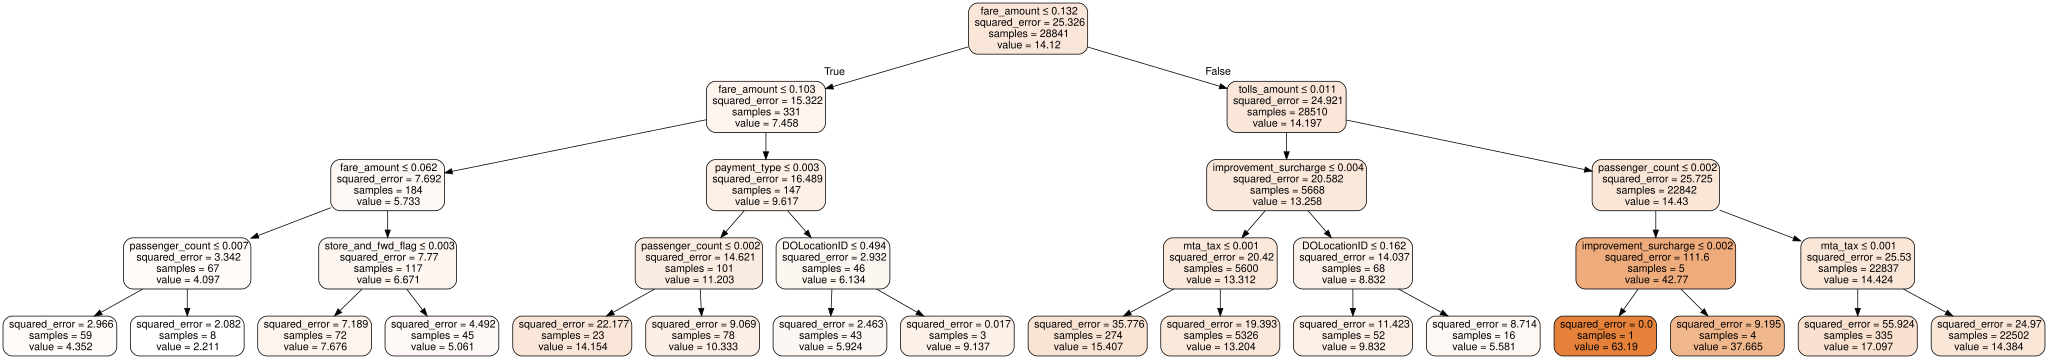

In [25]:
display(graph)

## Summary:

### Data Analysis Key Findings

*   A Decision Tree Regressor model with the optimal `max_depth` of 4 was successfully trained on the training data.
*   The decision tree model was successfully exported to a PNG file named `optimal_decision_tree.png` and displayed.

### Insights or Next Steps

*   Analyze the generated decision tree visualization to understand the key features and splits influencing the model's predictions.
